In [1]:
from timeit import timeit

import onnxruntime as ort
import torch
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer

In [2]:
torch.set_float32_matmul_precision('high')

In [3]:
# Generated by gemini - should contain approximately 200 words (models was trained on 250 words max)
sentence = "The elderly, distinguished professor, Dr. Alistair Finch, known internationally for his groundbreaking research into late-nineteenth-century Neo-Gothic architectural revival movements, and moreover, his surprising, perhaps even eccentric, habit of wearing a vividly colored, hand-knitted scarf, even during the oppressive heat of midsummer academic conferences, a truly peculiar choice that often drew whispered comments and speculative glances from his more conservatively dressed, tweed-jacket-wearing colleagues, including the notoriously critical Dr. Evelyn Reed, who specialized in early Byzantine mosaics and considered Finch’s fashion sense a regrettable distraction from serious intellectual pursuits, slowly, deliberately, and with an air of profound, almost religious contemplation—which suggested the immense weight of the information he was about to deliver to the assembled student body and faculty members, a group encompassing nervous undergraduates, jaded graduate researchers working tirelessly on their dissertations, and skeptical tenured department heads—stepped up to the podium, adjusted the microphone, cleared his throat with a resonant, theatrical sound that echoed momentarily throughout the vast, high-ceilinged lecture hall, and finally, after what felt like an eternity to the impatient audience gathered there, began to speak about the recently discovered, remarkably preserved, and potentially world-altering archives pertaining to the elusive master builder, Elias Thorne."
len(sentence.split())

195

In [4]:
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/multi-qa-mpnet-base-cos-v1")
tokens = tokenizer(sentence, return_tensors="pt").to('cuda')

In [5]:
def load_model():
    return AutoModel.from_pretrained("sentence-transformers/multi-qa-mpnet-base-cos-v1")

In [6]:
timings = {}

In [7]:
warmup = lambda model: model(**tokens)
measure = lambda model: timeit(lambda: model(**tokens), number=100) / 100

In [8]:
model_baseline = load_model()
model_baseline.to('cuda')
timings["Torch Baseline"] = measure(model_baseline)
timings["Torch Baseline"]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

0.01921452037000563

In [9]:
model_eval = load_model()
model_eval.to('cuda')
model_eval.eval()
timings["Eval Mode"] = measure(model_eval)
timings["Eval Mode"]

0.01117034175000299

In [10]:
model_eval_no_grad = load_model()
model_eval_no_grad.to('cuda')
model_eval_no_grad.eval()

with torch.no_grad():
    timings["Eval Mode with No Grad"] = measure(model_eval_no_grad)

timings["Eval Mode with No Grad"]

0.014224366739981634

In [11]:
model_eval_inference_mode = load_model()
model_eval_inference_mode.to('cuda')
model_eval_inference_mode.eval()

with torch.inference_mode():
    timings["Eval Mode with Inference Mode"] = measure(model_eval_inference_mode)

timings["Eval Mode with Inference Mode"]

0.0072622311300074216

In [12]:
def compilation_warmup():
    model_compile = load_model()
    model_compile.to('cuda')
    model_compile.eval()
    model_compile = torch.compile(model_compile)
    with torch.inference_mode():
        warmup(model_compile)

In [13]:
timeit(compilation_warmup, number=1)

2.6317509209984564

In [14]:
model_eval_compiled = load_model()
model_eval_compiled.to('cuda')
model_eval_compiled.eval()
model_eval_compiled = torch.compile(model_eval_compiled)

with torch.inference_mode():
    warmup(model_eval_compiled)
    timings["Eval Mode with Inference Mode and Compiled"] = measure(model_eval_compiled)

timings["Eval Mode with Inference Mode and Compiled"]

0.003871024309992208

In [15]:
def plot_timings(timings):
    plt.barh(timings.keys(), timings.values())
    plt.xlabel("Time average (s) for 100 runs")
    plt.title("Performance Comparison")
    plt.show()

In [16]:
def plot_speedup(timings, baseline_key='Torch Baseline'):
    baseline = timings[baseline_key]
    speedups = {k: baseline / v for k, v in timings.items()}

    plt.barh(speedups.keys(), speedups.values())
    plt.xlabel("Speedup Factor")
    plt.title(f"Speedup Relative to {baseline_key}")
    plt.show()

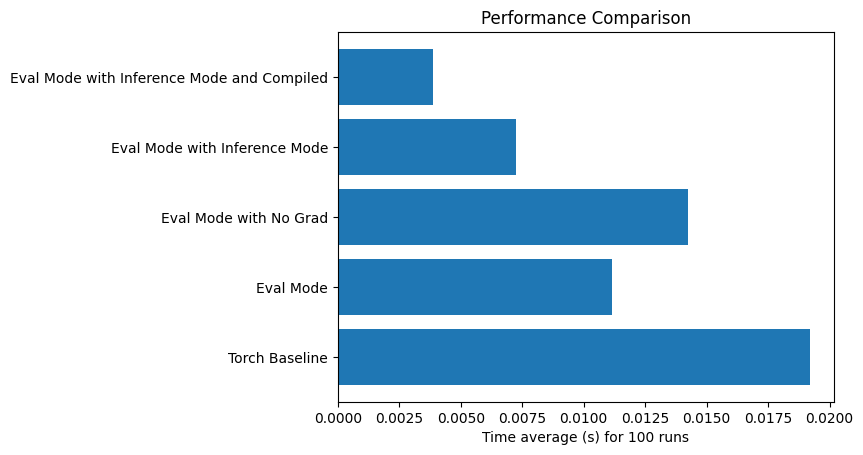

In [17]:
plot_timings(timings)

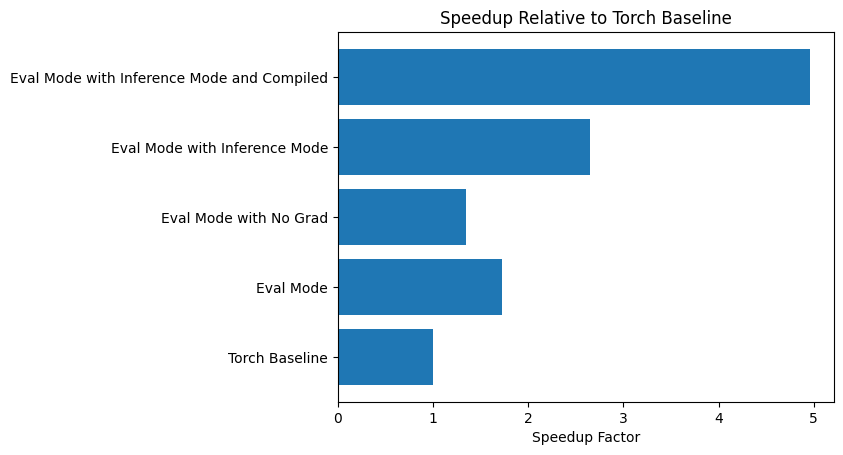

In [18]:
plot_speedup(timings, baseline_key='Torch Baseline')

As expected, each method allowed to improve the inference speed. The biggest boost came from using `torch.inference_mode()` along with `torch.compile()` (approximately 1.4x speedup compared to baseline). Simple `model.eval()` call provided 20% speedup, so it is definitely worth using it during inference.

## Excercise 3

In [19]:
model_cpu = load_model()
model_cpu.to('cpu')

model_quantized = torch.ao.quantization.quantize_dynamic(model_cpu, {torch.nn.Linear}, dtype=torch.qint8)

/tmp/ipykernel_299385/1175681624.py:4: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = torch.ao.quantization.quantize_dynamic(model_cpu, {torch.nn.Linear}, dtype=torch.qint8)


In [20]:
model_quantized

MPNetModel(
  (embeddings): MPNetEmbeddings(
    (word_embeddings): Embedding(30527, 768, padding_idx=1)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): MPNetEncoder(
    (layer): ModuleList(
      (0-11): 12 x MPNetLayer(
        (attention): MPNetAttention(
          (attn): MPNetSelfAttention(
            (q): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
            (k): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
            (v): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
            (o): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
            (dropout): Dropout(p=0.1, inplace=F

In [21]:
torch.save(model_cpu.state_dict(), "models/model_original.pth")
torch.save(model_quantized.state_dict(), "models/model_quantized.pth")

In [22]:
import os

print("Original model size (MB):", os.path.getsize("models/model_original.pth") / 1e6)
print("Quantized model size (MB):", os.path.getsize("models/model_quantized.pth") / 1e6)

Original model size (MB): 438.022092
Quantized model size (MB): 181.505477


The size reduced from 440 MB to 180 MB, which is approximately 2.5x smaller - a significant reduction for a model of this size.

In [23]:
tokens_cpu = tokenizer(sentence, return_tensors="pt").to('cpu')

In [24]:
timings_cpu = {}

In [25]:
model_cpu.eval()
with torch.inference_mode():
    timings_cpu["Original CPU"] = timeit(lambda: model_cpu(**tokens_cpu), number=100) / 100

timings_cpu["Original CPU"]

0.10263354827002331

In [26]:
model_quantized.eval()
with torch.inference_mode():
    timings_cpu["Quantized CPU"] = timeit(lambda: model_quantized(**tokens_cpu), number=100) / 100

timings_cpu["Quantized CPU"]

0.0861816042999999

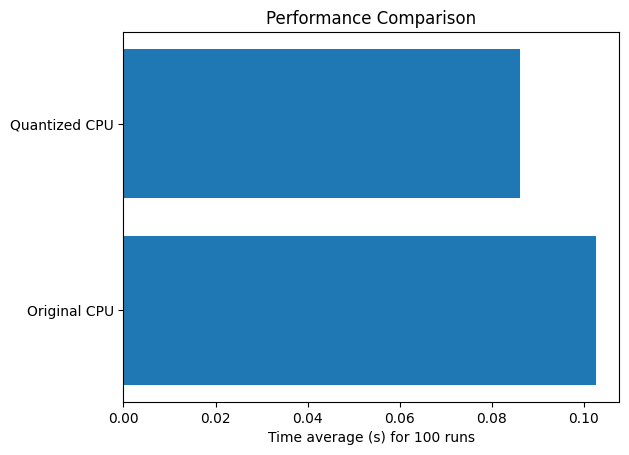

In [27]:
plot_timings(timings_cpu)

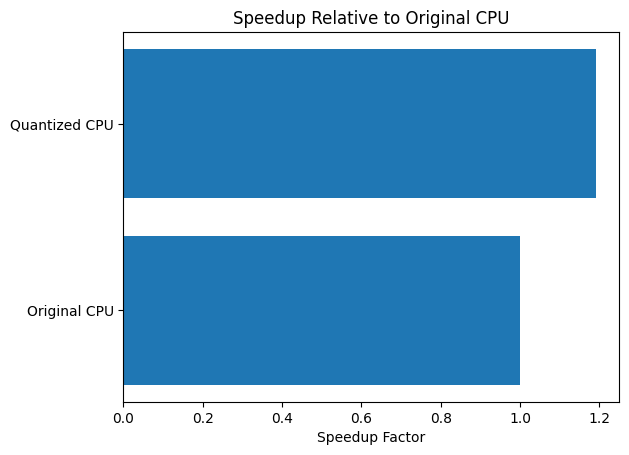

In [28]:
plot_speedup(timings_cpu, baseline_key='Original CPU')

The speed difference isn't very significant on CPU for this model - only about 1.2x speedup. However, the model is quite small, so maybe the quantization would work better on larger models.

## Excercise 3

In [18]:
timings_compile = {}

In [19]:
torch.cuda.empty_cache()

model_compile_default = load_model()
model_compile_default.to('cuda')
model_compile_default.eval()

model_compile_default = torch.compile(model_compile_default)

with torch.inference_mode():
    warmup(model_compile_default)
    timings_compile["Default Compile"] = measure(model_compile_default)

timings_compile["Default Compile"]

0.004887618830002794

In [20]:
torch.cuda.empty_cache()

model_compile_autotune = load_model()
model_compile_autotune.to('cuda')
model_compile_autotune.eval()

model_compile_autotune = torch.compile(model_compile_autotune, mode="max-autotune", dynamic=False)

with torch.inference_mode():
    warmup(model_compile_autotune)
    timings_compile["Max Autotune"] = measure(model_compile_autotune)

timings_compile["Max Autotune"]

0.00023401239000122586

In [21]:
torch.cuda.empty_cache()

model_compile_no_cudagraphs = load_model()
model_compile_no_cudagraphs.to('cuda')
model_compile_no_cudagraphs.eval()

model_compile_no_cudagraphs = torch.compile(model_compile_no_cudagraphs, mode="max-autotune-no-cudagraphs", dynamic=False)

with torch.inference_mode():
    warmup(model_compile_no_cudagraphs)
    timings_compile["Max Autotune No Cudagraphs"] = measure(model_compile_no_cudagraphs)

timings_compile["Max Autotune No Cudagraphs"]

W1130 04:03:13.039000 39666 Solutions/lab07/.venv/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:1358] [0/8] torch._dynamo hit config.recompile_limit (8)
W1130 04:03:13.039000 39666 Solutions/lab07/.venv/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:1358] [0/8]    function: 'forward' (/home/patryk/Documents/umisi/sem2/Solutions/lab07/.venv/lib/python3.12/site-packages/transformers/models/mpnet/modeling_mpnet.py:449)
W1130 04:03:13.039000 39666 Solutions/lab07/.venv/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:1358] [0/8]    last reason: 0/7: 
W1130 04:03:13.039000 39666 Solutions/lab07/.venv/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:1358] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W1130 04:03:13.039000 39666 Solutions/lab07/.venv/lib/python3.12/site-packages/torch/_dynamo/convert_frame.py:1358] [0/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.htm

0.003651824270000361

In [12]:
plot_timings(timings_compile)

NameError: name 'plot_timings' is not defined

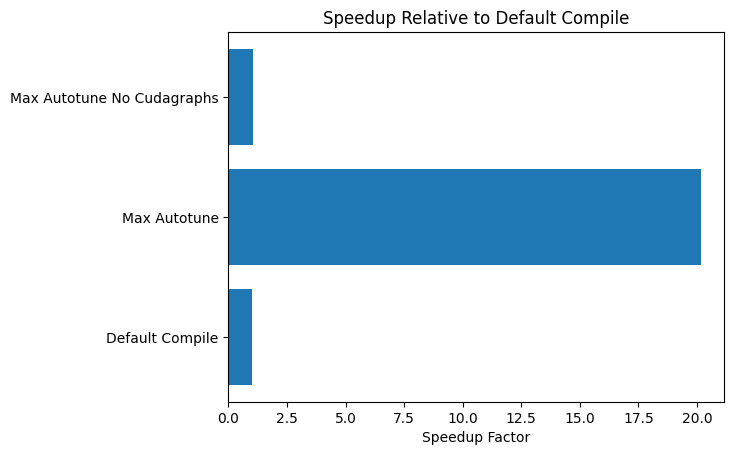

In [35]:
plot_speedup(timings_compile, baseline_key='Default Compile')

Torch autotuning completely dominated other compilation modes, providing about 20x speedup compared to default compilation. The no-cudagraphs performed similarly as default compilation, which only shows that cudagraphs are essential for good performance on GPU.

### Different input size

In [22]:
tokens_small = tokenizer("What's up?", return_tensors="pt").to('cuda')

In [23]:
def test_on_small_input(m):
    with torch.inference_mode():
        return timeit(lambda: m(**tokens_small), number=100) / 100

In [24]:
test_on_small_input(model_compile_default)

0.0012989470699994853

In [25]:
test_on_small_input(model_compile_autotune)

0.0002647203000014997

In [26]:
test_on_small_input(model_compile_no_cudagraphs)

0.002614687549998962

What was observed - if `dynamic=True` no model needs to recompile, but then the default one is faster than the others. If `dynamic=False`, they need to recompile and are even slower.

## Excercise 5

In [41]:
import torch

capability = torch.cuda.get_device_capability()
print(f"CUDA device capability: {capability}")

# Tensor Cores are available on NVidia GPUs with CUDA >= 7 (e.g. Volta, Turing, Ampere, Hopper)
if capability >= (7, 0):
    print("Tensor Cores available: fast float16 supported.")
else:
    print("Tensor Cores not available: float16 may be slow or unsupported.")

CUDA device capability: (8, 9)
Tensor Cores available: fast float16 supported.


In [42]:
timings_mixed = {}

In [43]:
model_fp32 = load_model()
model_fp32.to('cuda')
model_fp32.eval()

with torch.inference_mode():
    timings_mixed["Float32"] = timeit(lambda: model_fp32(**tokens), number=1000) / 1000

timings_mixed["Float32"]

0.005714708589999645

In [44]:
model_fp16 = load_model()
model_fp16.to('cuda')
model_fp16 = model_fp16.half()
model_fp16.eval()

tokens_half = {k: v.half().long() for k, v in tokens.items()}

with torch.inference_mode():
    timings_mixed["Float16"] = timeit(lambda: model_fp16(**tokens_half), number=1000) / 1000

timings_mixed["Float16"]

0.0027368074229998456

In [45]:
model_autocast = load_model()
model_autocast.to('cuda')
model_autocast.eval()

with torch.inference_mode(), torch.amp.autocast('cuda'):
    timings_mixed["Autocast Float16"] = timeit(lambda: model_autocast(**tokens), number=1000) / 1000

timings_mixed["Autocast Float16"]

0.0029965529139990396

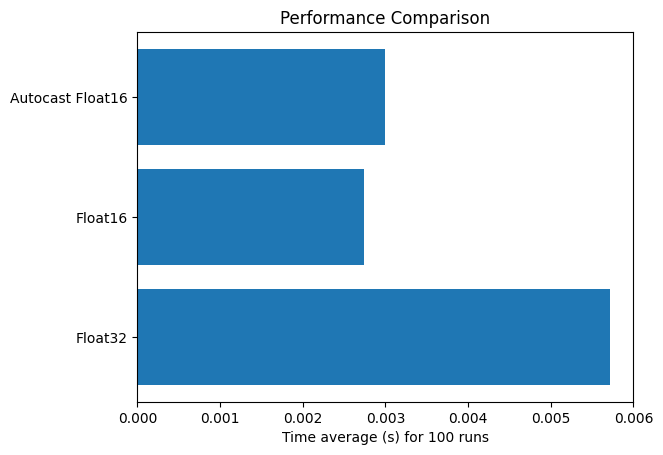

In [46]:
plot_timings(timings_mixed)

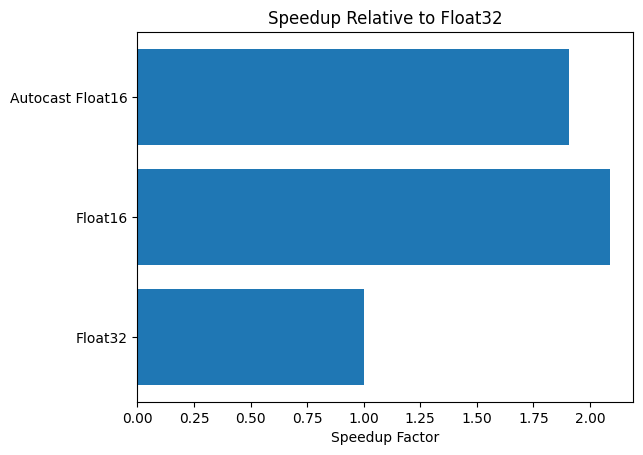

In [47]:
plot_speedup(timings_mixed, baseline_key='Float32')

Using autocast is a little bit slower than using float16 directly, but it is much more convenient to use, so I'd go with that approach in most cases, unless the absolute maximum performance is required. Both autocast and float16 provide approximately 1.4-1.5x speedup compared to float32.

## ONNX

In [48]:
import torch
import torch.onnx

# Put the model in eval mode and move to CPU
model_onnx_cpu = load_model().eval().cpu()

# Example input for tracking (for onnx export)
sample_input = tokenizer(
    "This is a sample input text for ONNX export.",
    padding=True,
    truncation=True,
    return_tensors="pt",
)

# Export to ONNX format
torch.onnx.export(
    model_onnx_cpu,
    (sample_input["input_ids"], sample_input["attention_mask"]),
    "models/model.onnx",
    opset_version=17,
    input_names=["input_ids", "attention_mask"],
    output_names=["output"],
    dynamic_axes={
        "input_ids": {0: "batch_size", 1: "sequence_length"},
        "attention_mask": {0: "batch_size", 1: "sequence_length"},
        "output": {0: "batch_size"},
    },
)

print("ONNX model exported successfully.")

/tmp/ipykernel_299385/2053023483.py:16: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W1130 02:47:59.606000 299385 Solutions/lab07/.venv/lib/python3.12/site-packages/torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W1130 02:47:59.847000 299385 Solutions/lab07/.venv/lib/python3.12/site-packages/torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skippin

[torch.onnx] Obtain model graph for `MPNetModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MPNetModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 83 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 17},
            producer_name='pytorch',
            producer_version='2.9.1+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input_ids"<INT64,[s43,s53]>,
                %"attention_mask"<INT64,[s43,s53]>
            ),
            outputs=(
                %"output"<FLOAT,[1,s53,768]>,
                %"tanh"<FLOAT,[1,768]>
            ),
            initializers=(
                %"embeddings.LayerNorm.weight"<FLOAT,[768]>{TorchTensor(...)},
                %"embeddings.LayerNorm.bias"<FLOAT,[768]>{TorchTensor(...)},
                %"encoder.layer.0.attention.attn.q.bias"<FLOAT,[768]>{TorchTensor(...)},
                %"encoder.layer.0.attention.attn.k.bias"<FLOAT,[768]>{TorchTensor(...)},
                %"encoder.layer.0.attention.attn.v.bias"<FLOAT,[768]>{TorchTensor(...)},
     

In [58]:
def online_mode():
    options = ort.SessionOptions()
    options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

    ort_session = ort.InferenceSession(
        "models/model.onnx", sess_options=options, providers=["CPUExecutionProvider"]
    )
    return ort_session

In [50]:
timeit(online_mode, number=100) / 100

0.13943786430001637

In [51]:
import onnxruntime as ort

sess_options = ort.SessionOptions()

# Choose the optimization level for the offline pass
sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

# Save the optimized model to this path
sess_options.optimized_model_filepath = "models/model_optimized.onnx"

# Create InferenceSession, which will perform offline optimization and save the optimized model
ort.InferenceSession("models/model.onnx", sess_options)

2025-11-30 02:48:19.598272792 [W:onnxruntime:, inference_session.cc:2473 Initialize] Serializing optimized model with Graph Optimization level greater than ORT_ENABLE_EXTENDED and the NchwcTransformer enabled. The generated model may contain hardware specific optimizations, and should only be used in the same environment the model was optimized in.


In [52]:
def offline_mode():
    options = ort.SessionOptions()
    options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_DISABLE_ALL

    ort_session = ort.InferenceSession(
        "models/model_optimized.onnx", sess_options=options, providers=["CPUExecutionProvider"]
    )
    return ort_session

In [53]:
online_mode()

In [54]:
timeit(offline_mode, number=100) / 100

0.14793367351998313

In [55]:
def measure_onnx_inference(load_session, input_tokens):
    input_dict = {
        "input_ids": input_tokens["input_ids"].cpu().numpy(),
        "attention_mask": input_tokens["attention_mask"].cpu().numpy(),
    }
    return timeit(lambda: load_session().run(None, input_dict), number=100) / 100

In [56]:
measure_onnx_inference(online_mode, tokens)

0.2350128302200028

In [57]:
measure_onnx_inference(offline_mode, tokens)

0.23177828431998931

On my machine, there was no difference between online and offline modes. This is probably because the model is relatively small and most time is spent in IO/parsing rather than actual optimization.

## Excercise 6 - Docker

There are two docker images prepared for this lab:
1. `torch_inference` - contains PyTorch model and inference endpoint. The model is quantized, compiled with `torch.compile()` and uses `torch.inference_mode()` for inference on CPU.
2. `onnx_inference` - contains ONNX model and inference endpoint. The model is optimized using ONNX Runtime optimizations.

Before building images, make sure that model files (`model_quantized.pth`, `model_optimized.onnx` and `model.onnx.data`) are present in the `lab07` folder.

Both can be build by running `docker compose build` in the `lab07` folder. Then, the containers can be started by running `docker compose up -d`.

The script that tests both endpoints is provided in the `test_endpoints.py` file. It sends a sample request to both endpoints 100 times and measures the average response time.

### Image sizes

```txt
IMAGE                                      ID             DISK USAGE   CONTENT SIZE   EXTRA
lab07-onnx-inference:latest                5f2be6ad2577        839MB             0B    U
lab07-torch-inference:latest               ea6331302c91       1.22GB             0B    U
```

As we can see, the ONNX image is significantly smaller (about 1.5x) than the PyTorch image, which is expected due to the smaller size of the ONNX model.

### Inference speed

```bash
(mlops-course-agh-lab-07) ➜  lab07 git:(master) ✗ python test_performance.py
Torch Inference average inference time over 100 runs: 0.1690 seconds
ONNX Inference average inference time over 100 runs: 0.0617 seconds
```

Torch inference endpoint was about 2.7x slower than ONNX endpoint on CPU. This is a huge difference, as it is exactly the same model used in both cases. What's more surprising, that the for PyTorch model there was few optimizations applied (quantization, compilation, inference mode), while the ONNX model was just optimized using default ONNX Runtime optimizations.